## 什么是神经网络？

神经网络是一种受人脑结构启发的机器学习模型：

- **神经元（Neuron）**：基本计算单元，接收输入并产生输出
- **层（Layer）**：神经元的集合，包括输入层、隐藏层和输出层
- **权重（Weight）**：连接强度，决定信号的重要性
- **激活函数（Activation）**：引入非线性，使网络能学习复杂模式

### 为什么需要神经网络？

| 模型 | 决策边界 | 适用场景 |
|------|----------|----------|
| 逻辑回归 | 线性 | 简单分类 |
| 神经网络 | 非线性、复杂 | 图像、语音、文本 |

> **神经网络是通用函数逼近器** — 理论上可以拟合任何连续函数！

# 神经网络基础
## Neural Network Fundamentals

---

**课程 3 - 神经网络入门**

本讲座将介绍：
- 神经网络的基本概念
- 使用 PyTorch 构建神经网络
- 手写数字识别实战

## 为什么选择 PyTorch？

**PyTorch** 是由 Facebook 开发的深度学习框架，具有以下优势：

1. **动态计算图** — 更灵活，易于调试
2. **Pythonic** — 代码简洁，符合 Python 习惯
3. **强大的生态系统** — torchvision, torchtext 等
4. **研究友好** — 大多数 AI 论文使用 PyTorch 实现
5. **生产部署** — TorchScript, ONNX 支持

```python
# PyTorch 核心组件
import torch                    # 张量运算
import torch.nn as nn          # 神经网络模块
import torch.optim as optim    # 优化器
from torch.utils.data import DataLoader  # 数据加载
```

## 导入必要的库

我们将使用以下库：
- `torch` — PyTorch 核心库
- `torchvision` — 计算机视觉工具
- `matplotlib` — 可视化
- `numpy` — 数值计算
- `pandas` — 数据处理

In [17]:
# 导入必要的库
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子，确保结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 检查是否有 GPU 可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备：{device}')

使用设备：cpu


## 加载 MNIST 数据集

### MNIST 数据集介绍

MNIST 是一个经典的手写数字数据集：

- **图片数量**：60,000 张训练图 + 10,000 张测试图
- **图片尺寸**：28×28 像素，灰度图
- **标签**：0-9 共 10 个数字
- **用途**：图像分类的"Hello World"

### 数据来源

我们使用本地 CSV 文件（避免网络问题）：
- `mnist_train.csv` — 训练数据
- `mnist_test.csv` — 测试数据

In [18]:
# 从本地 CSV 加载数据
print('正在加载训练数据...')
train_df = pd.read_csv('mnist_train.csv', header=0)
test_df = pd.read_csv('mnist_test.csv', header=0)

print(f'训练数据形状：{train_df.shape}')
print(f'测试数据形状：{test_df.shape}')

正在加载训练数据...
训练数据形状：(6000, 785)
测试数据形状：(1000, 785)


In [19]:
# 分离特征和标签
# 第一列是标签，其余 784 列是像素值
x_train = train_df.iloc[:, 1:].values.astype(np.float32)
y_train = train_df.iloc[:, 0].values.astype(np.int64)
x_test = test_df.iloc[:, 1:].values.astype(np.float32)
y_test = test_df.iloc[:, 0].values.astype(np.int64)

print(f'训练特征形状：{x_train.shape}')  # (60000, 784)
print(f'训练标签形状：{y_train.shape}')  # (60000,)
print(f'测试特征形状：{x_test.shape}')   # (10000, 784)
print(f'测试标签形状：{y_test.shape}')   # (10000,)

训练特征形状：(6000, 784)
训练标签形状：(6000,)
测试特征形状：(1000, 784)
测试标签形状：(1000,)


## 数据预处理

### 为什么要预处理？

1. **归一化** — 将像素值缩放到 [0, 1] 范围，加速训练收敛
2. **重塑** — 将 784 维向量转为 28×28 图像，便于可视化
3. **转换为张量** — PyTorch 需要 Tensor 格式

### 归一化公式

$$x_{normalized} = \frac{x}{255.0}$$

像素值范围从 [0, 255] 缩放到 [0, 1]

In [4]:
# 归一化像素值到 [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# 重塑为 28×28 图像（用于可视化）
x_train_img = x_train.reshape(-1, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)

# 转换为 PyTorch 张量
x_train_tensor = torch.from_numpy(x_train)
y_train_tensor = torch.from_numpy(y_train)
x_test_tensor = torch.from_numpy(x_test)
y_test_tensor = torch.from_numpy(y_test)

print(f'训练张量形状：{x_train_tensor.shape}')

训练张量形状：torch.Size([6000, 784])


## 可视化数据

让我们看看训练数据中的一些手写数字样本：

/tmp/ipykernel_427787/2856456586.py:9: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/2856456586.py:9: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/2856456586.py:9: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/giftia/miniconda3/envs/nn-lecture/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/giftia/miniconda3/envs/nn-lecture/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/giftia/miniconda3/envs/nn-lecture/lib/python3.10/site-packages/IPython/core/pyl

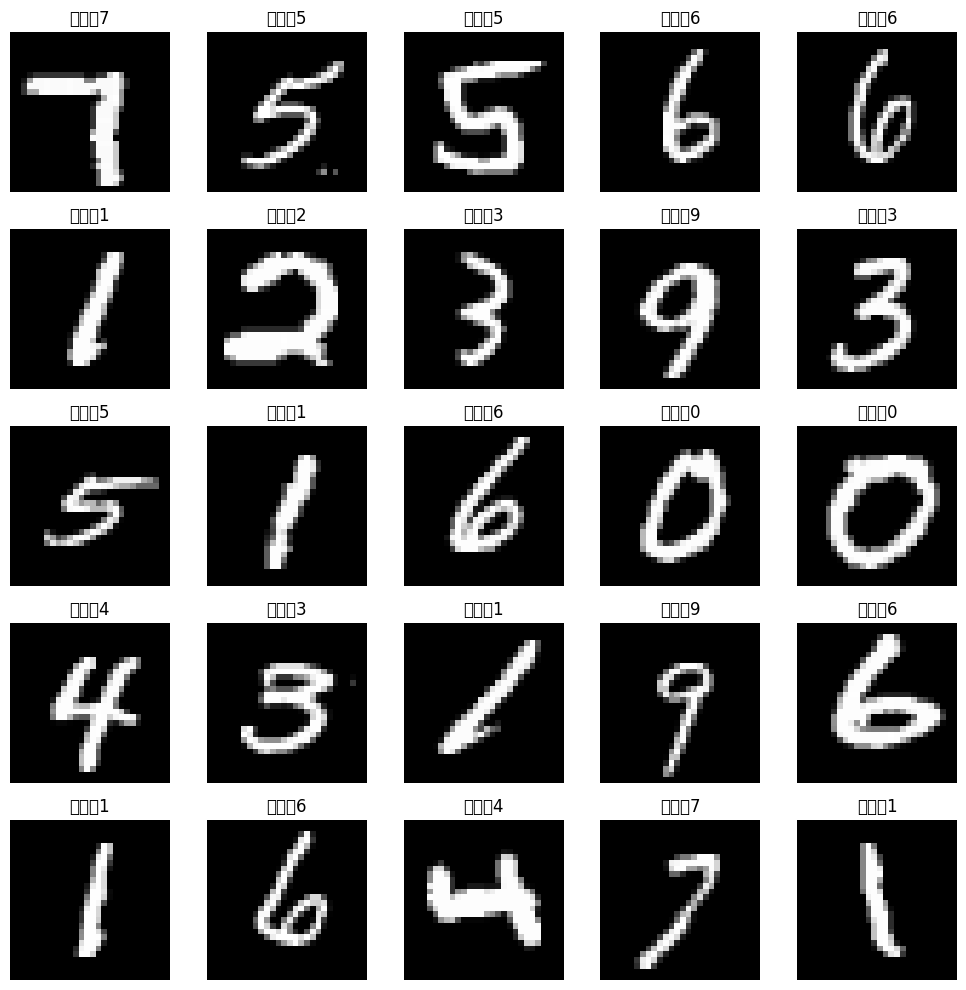

In [5]:
# 可视化 25 个随机样本
plt.figure(figsize=(10, 10))
for i in range(25):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_img[idx], cmap='gray')
    plt.title(f'标签：{y_train[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 统计标签分布

检查数据集是否平衡（每个数字的数量是否相近）：

In [6]:
# 统计训练集标签分布
unique, counts = np.unique(y_train, return_counts=True)
print('训练集标签分布:')
for label, count in zip(unique, counts):
    print(f'  数字 {label}: {count} 张 ({count/len(y_train)*100:.1f}%)')

print(f'\n总计：{len(y_train)} 张训练图片')

训练集标签分布:
  数字 0: 600 张 (10.0%)
  数字 1: 600 张 (10.0%)
  数字 2: 600 张 (10.0%)
  数字 3: 600 张 (10.0%)
  数字 4: 600 张 (10.0%)
  数字 5: 600 张 (10.0%)
  数字 6: 600 张 (10.0%)
  数字 7: 600 张 (10.0%)
  数字 8: 600 张 (10.0%)
  数字 9: 600 张 (10.0%)

总计：6000 张训练图片


## 创建 DataLoader

### 为什么需要 DataLoader？

DataLoader 提供以下功能：

1. **批量处理（Batching）** — 每次处理一小批数据，节省内存
2. **打乱数据（Shuffling）** — 每个 epoch 随机打乱，防止过拟合
3. **多进程加载** — 加速数据读取

### 关键参数

- `batch_size` — 每批处理的样本数（如 64, 128）
- `shuffle` — 是否打乱数据（训练时=True，测试时=False）

In [7]:
# 创建 TensorDataset
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# 创建 DataLoader
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # 训练时打乱数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # 测试时不打乱
)

print(f'训练批次数：{len(train_loader)}')  # 60000 / 64 = 937.5 ≈ 938
print(f'测试批次数：{len(test_loader)}')   # 10000 / 64 = 156.25 ≈ 157

训练批次数：94
测试批次数：16


## 构建神经网络模型

### 网络架构设计

我们将构建一个**多层感知机（MLP）**：

```
输入层 (784) → 隐藏层 1 (256) → ReLU → Dropout → 
              隐藏层 2 (128) → ReLU → Dropout → 
              输出层 (10) → Softmax
```

### 各层作用

| 层类型 | 作用 |
|--------|------|
| **Dense (Linear)** | 全连接层，学习特征组合 |
| **ReLU** | 激活函数，引入非线性 |
| **Dropout** | 随机丢弃神经元，防止过拟合 |
| **Softmax** | 输出概率分布（多分类） |

In [8]:
# 定义神经网络模型
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10, dropout_rate=0.3):
        super(MLP, self).__init__()
        
        # 第一层：输入 → 隐藏层 1
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # 第二层：隐藏层 1 → 隐藏层 2
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # 输出层：隐藏层 2 → 输出
        self.fc3 = nn.Linear(hidden2, num_classes)
        # 注意：Softmax 包含在 CrossEntropyLoss 中，不需要单独添加
    
    def forward(self, x):
        # 前向传播
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x

# 创建模型实例
model = MLP().to(device)
print('模型创建成功！')

模型创建成功！


## 查看模型结构

使用 `print()` 查看模型详细信息：

In [9]:
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'总参数量：{total_params:,}')
print(f'可训练参数：{trainable_params:,}')

# 详细计算：
# 第 1 层：784 × 256 + 256 = 200,960
# 第 2 层：256 × 128 + 128 = 32,896
# 输出层：128 × 10 + 10 = 1,290
# 总计：235,146

总参数量：235,146
可训练参数：235,146


## 定义损失函数和优化器

### 损失函数：Cross Entropy Loss

**交叉熵损失**用于多分类问题：

$$L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

- $y_i$ — 真实标签（one-hot 编码）
- $\hat{y}_i$ — 预测概率
- $C$ — 类别数（10 个数字）

> PyTorch 的 `nn.CrossEntropyLoss` 已经包含了 Softmax，所以模型输出不需要再加 Softmax

### 优化器：Adam

**Adam** 是最常用的优化器：
- 自适应学习率
- 收敛快，效果好
- 几乎不需要调参

In [11]:
# 定义损失函数
criterion = nn.CrossEntropyLoss()

# 定义优化器
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f'损失函数：CrossEntropyLoss')
print(f'优化器：Adam (lr={learning_rate})')

损失函数：CrossEntropyLoss
优化器：Adam (lr=0.001)


## 训练模型

### 训练流程

每个 epoch 包含以下步骤：

1. **前向传播** — 输入数据，计算预测
2. **计算损失** — 比较预测和真实标签
3. **反向传播** — 计算梯度
4. **更新参数** — 优化器更新权重

### 关键概念

- **Epoch** — 遍历整个训练集一次
- **Batch** — 每次处理的数据量
- **Iteration** — 一个 epoch 中的批次数

In [12]:
# 训练模型
num_epochs = 20

# 记录训练历史
train_losses = []
train_accs = []

print(f'开始训练，共 {num_epochs} 个 epoch...\n')

for epoch in range(num_epochs):
    model.train()  # 设置为训练模式
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 遍历每个 batch


开始训练，共 20 个 epoch...

Epoch [1/20] | Loss: 1.0640 | Accuracy: 67.57%
Epoch [2/20] | Loss: 0.4195 | Accuracy: 87.32%
Epoch [3/20] | Loss: 0.3086 | Accuracy: 90.85%
Epoch [4/20] | Loss: 0.2513 | Accuracy: 92.00%
Epoch [5/20] | Loss: 0.2117 | Accuracy: 93.35%
Epoch [6/20] | Loss: 0.1723 | Accuracy: 94.63%
Epoch [7/20] | Loss: 0.1506 | Accuracy: 95.37%
Epoch [8/20] | Loss: 0.1263 | Accuracy: 95.98%
Epoch [9/20] | Loss: 0.1070 | Accuracy: 96.60%
Epoch [10/20] | Loss: 0.0866 | Accuracy: 97.37%
Epoch [11/20] | Loss: 0.0807 | Accuracy: 97.63%
Epoch [12/20] | Loss: 0.0743 | Accuracy: 97.72%
Epoch [13/20] | Loss: 0.0564 | Accuracy: 98.38%
Epoch [14/20] | Loss: 0.0492 | Accuracy: 98.25%
Epoch [15/20] | Loss: 0.0479 | Accuracy: 98.63%
Epoch [16/20] | Loss: 0.0394 | Accuracy: 98.78%
Epoch [17/20] | Loss: 0.0399 | Accuracy: 98.87%
Epoch [18/20] | Loss: 0.0360 | Accuracy: 98.85%
Epoch [19/20] | Loss: 0.0313 | Accuracy: 99.12%
Epoch [20/20] | Loss: 0.0294 | Accuracy: 99.23%

训练完成！


In [ ]:
for batch_idx, (inputs, targets) in enumerate(train_loader):
        # 将数据移到设备上
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1. 前向传播
        outputs = model(inputs)
        
        # 2. 计算损失
        loss = criterion(outputs, targets)
        
        # 3. 反向传播
        optimizer.zero_grad()  # 清空梯度
        loss.backward()        # 计算梯度
        optimizer.step()       # 更新参数
        
        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    # 计算 epoch 平均损失和准确率


In [ ]:
epoch_loss = running_loss / len(train_loader)
epoch_acc = 100.0 * correct / total

train_losses.append(epoch_loss)
train_accs.append(epoch_acc)

print(f'Epoch [{epoch+1}/{num_epochs}] | '
      f'Loss: {epoch_loss:.4f} | '
      f'Accuracy: {epoch_acc:.2f}%')

print('\n训练完成！')


## 可视化训练过程

绘制损失和准确率曲线，观察模型是否收敛：

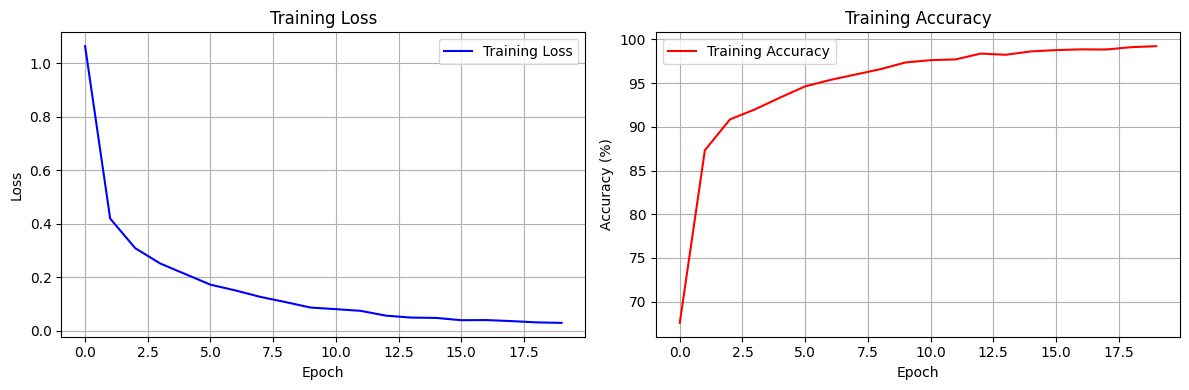

In [13]:
# 绘制训练曲线
plt.figure(figsize=(12, 4))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(train_accs, 'r-', label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 评估模型性能

在测试集上评估模型的泛化能力：

In [14]:
# 在测试集上评估
model.eval()  # 设置为评估模式

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():  # 不计算梯度
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

test_accuracy = 100.0 * correct / total
avg_test_loss = test_loss / len(test_loader)

print(f'测试集结果:')
print(f'  平均损失：{avg_test_loss:.4f}')
print(f'  准确率：{test_accuracy:.2f}%')
print(f'  正确预测：{correct}/{total}')

测试集结果:
  平均损失：0.3278
  准确率：92.50%
  正确预测：925/1000


## 混淆矩阵

分析模型在每个类别上的表现：

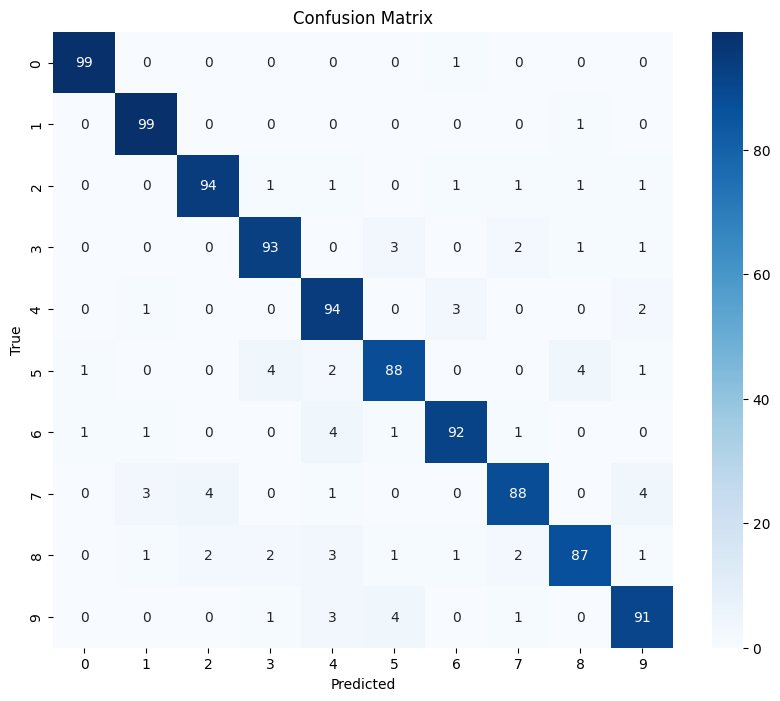


分类报告:
              precision    recall  f1-score   support

           0     0.9802    0.9900    0.9851       100
           1     0.9429    0.9900    0.9659       100
           2     0.9400    0.9400    0.9400       100
           3     0.9208    0.9300    0.9254       100
           4     0.8704    0.9400    0.9038       100
           5     0.9072    0.8800    0.8934       100
           6     0.9388    0.9200    0.9293       100
           7     0.9263    0.8800    0.9026       100
           8     0.9255    0.8700    0.8969       100
           9     0.9010    0.9100    0.9055       100

    accuracy                         0.9250      1000
   macro avg     0.9253    0.9250    0.9248      1000
weighted avg     0.9253    0.9250    0.9248      1000



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 收集所有预测和真实标签
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.numpy())

# 绘制混淆矩阵
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 分类报告
print('\n分类报告:')
print(classification_report(all_labels, all_preds, digits=4))

## 可视化预测结果

随机选择一些测试样本，查看模型的预测：

/tmp/ipykernel_427787/3869382051.py:25: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/3869382051.py:25: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/3869382051.py:25: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/3869382051.py:25: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_427787/3869382051.py:25: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/giftia/miniconda3/envs/nn-lecture/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gifti

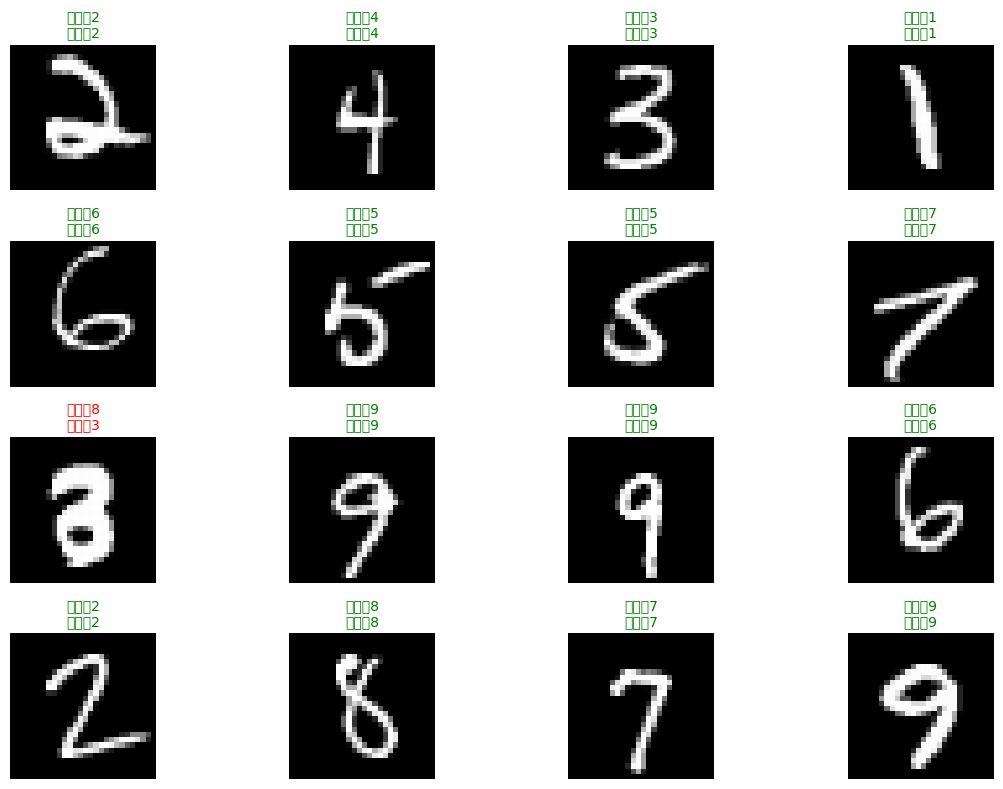

In [16]:
# 可视化预测结果
model.eval()
with torch.no_grad():
    # 随机选择 16 个测试样本
    idx = np.random.randint(0, len(x_test), size=16)
    samples = torch.from_numpy(x_test[idx]).to(device)
    true_labels = y_test[idx]
    
    outputs = model(samples)
    _, preds = outputs.max(1)
    pred_labels = preds.cpu().numpy()
    
    # 绘制
    plt.figure(figsize=(12, 8))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x_test_img[idx[i]], cmap='gray')
        
        # 颜色：绿色=正确，红色=错误
        color = 'green' if pred_labels[i] == true_labels[i] else 'red'
        plt.title(f'预测：{pred_labels[i]}\n真实：{true_labels[i]}',
                 color=color, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## 总结

### 本讲座要点

1. **神经网络基础**
   - 神经网络是通用函数逼近器
   - 可以学习复杂的非线性关系

2. **PyTorch 框架**
   - 动态计算图，灵活易用
   - 核心组件：Tensor, nn.Module, DataLoader

3. **模型构建流程**
   - 数据加载和预处理
   - 定义网络架构
   - 选择损失函数和优化器
   - 训练和评估

4. **关键概念**
   - Batch, Epoch, Iteration
   - Dropout 防止过拟合
   - ReLU 激活函数

## 下一步学习

### 进阶主题

1. **卷积神经网络（CNN）**
   - 更适合图像处理
   - 使用卷积层和池化层

2. **超参数调优**
   - 学习率调整策略
   - 网络深度和宽度
   - Dropout 比例

3. **正则化技术**
   - L2 正则化
   - Batch Normalization
   - Data Augmentation

4. **预训练模型**
   - Transfer Learning
   - Fine-tuning

## 参考资料

### PyTorch 官方资源
- [PyTorch 教程](https://pytorch.org/tutorials/)
- [PyTorch 文档](https://pytorch.org/docs/)

### 深度学习课程
- [Deep Learning Specialization (Coursera)](https://www.coursera.org/specializations/deep-learning)
- [Fast.ai](https://www.fast.ai/)

### 书籍
- 《Deep Learning》by Ian Goodfellow
- 《Deep Learning with PyTorch》

---

**感谢学习！有任何问题欢迎提问。** 🎓